# EEG-Based Seizure Detection

**Dataset:** CHB-MIT Scalp EEG Database (PhysioNet, Shoeb 2009)  
**Data:** Real clinical recordings — chb01_03.edf, subject chb01, 2 annotated seizures  
**Pipeline:** Download → Preprocess → Epoch → Feature Extraction → Classification → Evaluation

---
## Features extracted (matching SOP description)
1. **Spectral band power** across 5 frequency bands (delta, theta, alpha, beta, gamma) via Welch PSD
2. **Hjorth Complexity** — measures how rapidly frequency content changes over time
3. **Inter-channel correlation** — captures hypersynchrony during seizures
4. **Theta-gamma phase-amplitude coupling (PAC)** — Modulation Index (Canolty et al. 2006)

## How to run
1. Run Cell 1 (install), Cell 2 (imports)
2. Run Cell 3 — tries automatic download from PhysioNet
3. If download fails: run Cell 4 (manual upload) instead
4. Run Cells 5–16 in order


## Install Dependencies

!pip install mne imbalanced-learn -q  




In [1]:
!pip install mne imbalanced-learn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 83.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


## Imports


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import urllib.request
import os, shutil, warnings
warnings.filterwarnings('ignore')

import mne
mne.set_log_level('WARNING')

from scipy import signal
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from scipy.ndimage import binary_dilation, median_filter

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

np.random.seed(42)
print("All imports successful.")


All imports successful.


## Download Data and Load EDF

The CHB-MIT Scalp EEG Database (Shoeb, 2009) contains long-term  
EEG recordings from 22 pediatric epilepsy patients at 256 Hz,  
with clinically annotated seizure onset and offset times.  
We use chb01_03.edf which contains two confirmed seizures.  

This cell first tries to download automatically from PhysioNet.  
If that fails, it prints manual upload instructions.  
After upload, re-run from Cell 4 onwards.  



In [3]:
SEIZURE_ANNOTATIONS = {
    'chb01_03': [
        (2996, 3036),   # seizure 1: onset_sec, offset_sec
        (3368, 3426),   # seizure 2
    ]
}

DATA_DIR = './chbmit_data'
EDF_PATH = os.path.join(DATA_DIR, 'chb01_03.edf')
os.makedirs(DATA_DIR, exist_ok=True)

URL = 'https://physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf'

if not os.path.exists(EDF_PATH):
    print('Downloading chb01_03.edf from PhysioNet (~50MB)...')
    print('This may take 1-3 minutes depending on connection speed.')
    try:
        urllib.request.urlretrieve(URL, EDF_PATH)
        size_mb = os.path.getsize(EDF_PATH) / 1e6
        print(f'Download successful: {EDF_PATH}  ({size_mb:.1f} MB)')
    except Exception as e:
        print(f'Download failed: {e}')
        print()
        print('MANUAL UPLOAD INSTRUCTIONS:')
        print('  1. Go to: https://physionet.org/content/chbmit/1.0.0/chb01/')
        print('  2. Create a free PhysioNet account and accept the data use agreement')
        print('  3. Download chb01_03.edf to your computer')
        print('  4. Run the cell below (Manual Upload) to upload it here')
else:
    size_mb = os.path.getsize(EDF_PATH) / 1e6
    print(f'File already exists: {EDF_PATH}  ({size_mb:.1f} MB)')


This may take 1-3 minutes depending on connection speed.
Download successful: ./chbmit_data/chb01_03.edf  (42.4 MB)


## Manual Upload (only if Cell 3 download failed)

Uncomment and run this cell if the automatic download above failed.  

from google.colab import files  
print("Select chb01_03.edf from your computer...")  
uploaded = files.upload()  
fname = list(uploaded.keys())[0]  
os.makedirs('./chbmit_data', exist_ok=True)  
shutil.move(fname, './chbmit_data/chb01_03.edf')  
size_mb = os.path.getsize('./chbmit_data/chb01_03.edf') / 1e6  
print(f"Done. File saved ({size_mb:.1f} MB)")  




## Load and Inspect EDF

EDF (European Data Format) is the standard EEG file format.  
MNE reads it and gives us:  
sfreq    : sampling frequency (256 Hz for CHB-MIT)  
ch_names : electrode names in the standard 10-20 system  
data     : numpy array of shape (n_channels x n_samples)  
We convert raw data to microvolts (x 1e6) for numerical stability.  



In [4]:
assert os.path.exists(EDF_PATH), (
    f"\nFile not found: {EDF_PATH}\n"
    "Please run Cell 3 (automatic download) or Cell 4 (manual upload) first."
)

print("Loading EDF file...")
raw = mne.io.read_raw_edf(EDF_PATH, preload=True, verbose=False)

sfreq    = raw.info['sfreq']
ch_names = raw.ch_names
data, times = raw.get_data(return_times=True)

print(f"\nRecording summary:")
print(f"  Sampling frequency : {sfreq} Hz")
print(f"  Number of channels : {len(ch_names)}")
print(f"  Channel names      : {ch_names}")
print(f"  Duration           : {times[-1]:.1f}s  ({times[-1]/3600:.2f} hours)")
print(f"  Data shape         : {data.shape}  (channels x samples)")
print(f"\nAnnotated seizures in this file:")
for i, (onset, offset) in enumerate(SEIZURE_ANNOTATIONS['chb01_03']):
    print(f"  Seizure {i+1}: {onset}s — {offset}s  (duration: {offset-onset}s)")


Loading EDF file...

Recording summary:
  Sampling frequency : 256.0 Hz
  Number of channels : 23
  Channel names      : ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
  Duration           : 3600.0s  (1.00 hours)
  Data shape         : (23, 921600)  (channels x samples)

Annotated seizures in this file:
  Seizure 1: 2996s — 3036s  (duration: 40s)
  Seizure 2: 3368s — 3426s  (duration: 58s)


## Visualise Raw EEG Around First Seizure

Top panel: raw EEG voltage trace for channel FP1-F7.  
Inside the red shaded region (seizure window) you should see  
visibly higher amplitude and more rhythmic bursting.  

Bottom panel: spectrogram (short-time Fourier transform).  
X = time, Y = frequency, colour = power (dB, log scale).  
Brighter = more power at that frequency at that time.  
During seizure: broadband brightening especially in gamma (30-50 Hz).  



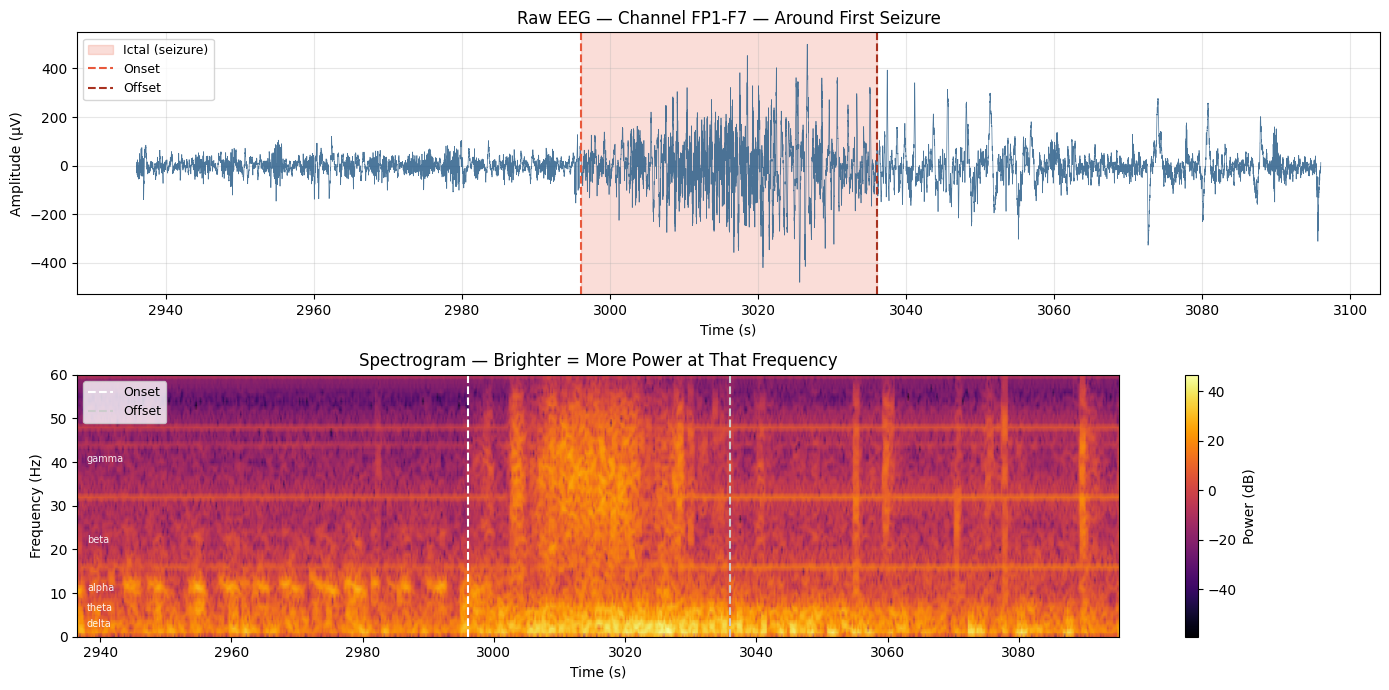

Saved: raw_eeg_visualization.png


In [5]:
BANDS = {
    'delta': (0.5,  4),
    'theta': (4,    8),
    'alpha': (8,   13),
    'beta':  (13,  30),
    'gamma': (30,  50),
}

onset_sec, offset_sec = SEIZURE_ANNOTATIONS['chb01_03'][0]
plot_start = max(0, onset_sec - 60)
plot_end   = offset_sec + 60
s_idx      = int(plot_start * sfreq)
e_idx      = int(plot_end   * sfreq)
ch_idx     = 0

t_plot  = np.arange(s_idx, e_idx) / sfreq
eeg_seg = data[ch_idx, s_idx:e_idx] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ax = axes[0]
ax.plot(t_plot, eeg_seg, lw=0.5, color='#2c5f8a', alpha=0.85)
ax.axvspan(onset_sec, offset_sec, color='#e8593c',
           alpha=0.2, label='Ictal (seizure)')
ax.axvline(onset_sec,  color='#e8593c', lw=1.5, ls='--', label='Onset')
ax.axvline(offset_sec, color='#a83220', lw=1.5, ls='--', label='Offset')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (μV)')
ax.set_title(f'Raw EEG — Channel {ch_names[ch_idx]} — Around First Seizure')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
f_sp, t_sp, Sxx = signal.spectrogram(
    eeg_seg, fs=sfreq, nperseg=256, noverlap=200)
t_sp_abs  = t_sp + plot_start
freq_mask = f_sp <= 60
pcm = ax2.pcolormesh(
    t_sp_abs, f_sp[freq_mask],
    10*np.log10(Sxx[freq_mask] + 1e-10),
    shading='gouraud', cmap='inferno')
ax2.axvline(onset_sec,  color='white', lw=1.5, ls='--', label='Onset')
ax2.axvline(offset_sec, color='#ccc',  lw=1.5, ls='--', label='Offset')
plt.colorbar(pcm, ax=ax2, label='Power (dB)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Frequency (Hz)')
ax2.set_title('Spectrogram — Brighter = More Power at That Frequency')
ax2.legend(loc='upper left', fontsize=9)
for bname, (lo, hi) in BANDS.items():
    ax2.text(plot_start+2, (lo+hi)/2, bname,
             color='white', fontsize=7, alpha=0.9)

plt.tight_layout()
plt.savefig('raw_eeg_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: raw_eeg_visualization.png")


## Preprocessing

Three standard clinical EEG preprocessing steps:  

1. Bandpass filter (0.5-50 Hz, zero-phase Butterworth order 4):  
Removes DC drift below 0.5 Hz (slow electrode movement artifacts).  
Removes noise above 50 Hz (muscle/EMG artifacts).  
filtfilt applies the filter forward then backward — no phase shift.  

2. Notch filter (50 Hz):  
Removes power-line interference.  
Use 60 Hz if recording from North America.  

3. Common Average Reference (CAR):  
Subtracts mean across all channels at each time point.  
Removes noise common to all electrodes (body movement,  
far-field electrical noise).  



In [6]:
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq  = fs / 2.0
    b, a = signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return signal.filtfilt(b, a, data, axis=-1)

def notch_filter(data, notch_freq, fs, quality=30):
    """Narrow band-stop filter for power-line frequency."""
    nyq  = fs / 2.0
    b, a = signal.iirnotch(notch_freq/nyq, quality)
    return signal.filtfilt(b, a, data, axis=-1)

def common_average_reference(data):
    """Subtract mean across all channels at every time point."""
    return data - data.mean(axis=0, keepdims=True)

print("Preprocessing...")
data_uv   = data * 1e6
data_filt = bandpass_filter(data_uv, 0.5, 50.0, sfreq)
print("  ✓ Bandpass filter (0.5–50 Hz)")
data_filt = notch_filter(data_filt, 50.0, sfreq)
print("  ✓ Notch filter (50 Hz)")
data_filt = common_average_reference(data_filt)
print("  ✓ Common average reference")
print(f"\nFiltered data shape: {data_filt.shape}  (channels x samples)")


Preprocessing...
  ✓ Bandpass filter (0.5–50 Hz)
  ✓ Notch filter (50 Hz)
  ✓ Common average reference

Filtered data shape: (23, 921600)  (channels x samples)


## Epoch Extraction and Labelling

We slice the continuous EEG into 4-second non-overlapping windows.  
Each window is labelled:  
1 = ictal     (seizure is occurring in this window)  
0 = interictal (no seizure)  

PERI-ICTAL BUFFER (±10 seconds around seizure boundaries):  
The transition into and out of a seizure has mixed spectral  
characteristics — not clearly ictal or interictal. Including  
these ambiguous epochs confuses the classifier. We exclude  
them using binary dilation of the seizure mask.  
This is standard practice in clinical EEG machine learning.  

Why 4-second epochs?  
Short enough for temporal resolution in onset detection.  
Long enough to capture full cycles of delta (0.5 Hz) and  
enough cycles of slower rhythms for reliable PSD estimation.  



In [7]:
EPOCH_SEC  = 4
EPOCH_SAMP = int(EPOCH_SEC * sfreq)
BUFFER_SEC = 10

n_total = data_filt.shape[1]

# Binary mask: True at every sample inside a seizure
seizure_mask = np.zeros(n_total, dtype=bool)
for onset_s, offset_s in SEIZURE_ANNOTATIONS['chb01_03']:
    seizure_mask[int(onset_s*sfreq):int(offset_s*sfreq)] = True

# Dilate mask to create peri-ictal buffer zone
struct       = np.ones(int(BUFFER_SEC * sfreq), dtype=bool)
buffer_mask  = binary_dilation(seizure_mask, structure=struct)
exclude_mask = buffer_mask & ~seizure_mask

epochs, labels = [], []
n_excluded = 0

for i in range(n_total // EPOCH_SAMP):
    start = i * EPOCH_SAMP
    end   = start + EPOCH_SAMP
    if end > n_total:
        break
    if exclude_mask[start:end].any():
        n_excluded += 1
        continue
    label = 1 if seizure_mask[start:end].any() else 0
    epochs.append(data_filt[:, start:end])
    labels.append(label)

epochs = np.array(epochs)
labels = np.array(labels)

print(f"Epochs extracted    : {len(epochs)}")
print(f"  Ictal   (label=1) : {labels.sum()}")
print(f"  Interictal (0)    : {(labels==0).sum()}")
print(f"  Excluded (buffer) : {n_excluded}")
print(f"  Imbalance ratio   : 1:{(labels==0).sum()//max(labels.sum(),1)}")
print(f"\nEpoch shape: {epochs.shape}  (epochs x channels x samples)")


Epochs extracted    : 892
  Ictal   (label=1) : 24
  Interictal (0)    : 868
  Excluded (buffer) : 8
  Imbalance ratio   : 1:36

Epoch shape: (892, 23, 1024)  (epochs x channels x samples)


## Feature Extraction

We extract four categories of features matching the SOP description:  

1. SPECTRAL BAND POWER (5 values per channel)  
Welch's method: divides epoch into overlapping sub-windows,  
computes periodogram for each, averages them (lower variance).  
Relative power = each band's area / total area (scale-invariant).  
Bands: delta(0.5-4), theta(4-8), alpha(8-13), beta(13-30), gamma(30-50)  
During seizure: theta↑, alpha↓, gamma↑  

2. HJORTH COMPLEXITY PARAMETER (1 value per channel)  
Hjorth (1970): measures how much frequency content changes over time.  
Complexity = mobility(x') / mobility(x)  
where mobility = std(derivative) / std(signal)  
Pure sine wave  → low complexity  (constant frequency)  
Ictal discharge → high complexity (frequency varies rapidly)  

3. INTER-CHANNEL CORRELATION (1 global value)  
Mean Pearson correlation across all electrode pairs.  
Seizures are HYPERSYNCHRONOUS — normally independent channels  
start moving together → correlation rises sharply during ictal.  

4. THETA-GAMMA PHASE-AMPLITUDE COUPLING / PAC (1 global value)  
Measures theta-gamma coupling using Modulation Index  
(Canolty et al., 2006):  
- Bandpass filter → theta (4-8 Hz) → extract phase via Hilbert  
- Bandpass filter → gamma (30-50 Hz) → extract amplitude envelope  
- MI = |mean(A_gamma * exp(i * phi_theta))|  
High MI → gamma bursts locked to a preferred theta phase (ictal)  
Low MI  → gamma amplitude independent of theta phase (interictal)  

Additional features for classification support:  
Spectral entropy, SEF95, variance, kurtosis, skewness, ZCR  



In [8]:
def compute_band_powers(x, fs, bands):
    """Welch PSD + relative band power per frequency band."""
    freqs, psd = signal.welch(x, fs=fs, nperseg=min(256, len(x)//2))
    total = np.trapz(psd, freqs) + 1e-10
    bp = {}
    for band, (lo, hi) in bands.items():
        idx = (freqs >= lo) & (freqs <= hi)
        bp[band] = np.trapz(psd[idx], freqs[idx]) / total if idx.any() else 0.0
    return freqs, psd, bp

def spectral_entropy(psd):
    """Shannon entropy of normalised PSD."""
    p = psd / (psd.sum() + 1e-10)
    return -np.sum(p * np.log2(p + 1e-10))

def spectral_edge_freq(psd, freqs, edge=0.95):
    """Frequency below which `edge` fraction of power falls."""
    cumulative = np.cumsum(psd) / (psd.sum() + 1e-10)
    idx = np.searchsorted(cumulative, edge)
    return freqs[min(idx, len(freqs)-1)]

def hjorth_complexity(x):
    """
    Hjorth Complexity = mobility(first derivative) / mobility(signal)
    where mobility(x) = std(dx/dt) / std(x)
    Captures how rapidly the dominant frequency changes over time.
    """
    d1 = np.diff(x)
    d2 = np.diff(d1)
    mob_x  = np.sqrt(np.var(d1) / (np.var(x)  + 1e-10))
    mob_d1 = np.sqrt(np.var(d2) / (np.var(d1) + 1e-10))
    return mob_d1 / (mob_x + 1e-10)

def theta_gamma_coupling(x, fs):
    """
    Theta-gamma phase-amplitude coupling using Modulation Index.
    Canolty et al. (2006), Science.

    High MI during seizures because gamma bursts are phase-locked
    to the theta rhythm — a hallmark of ictal hypersynchrony.
    """
    def bp_filt(sig, lo, hi, fs, order=3):
        nyq = fs / 2.0
        lo  = max(lo, 0.5)
        hi  = min(hi, nyq - 1.0)
        if lo >= hi:
            return np.zeros_like(sig)
        b, a = signal.butter(order, [lo/nyq, hi/nyq], btype='band')
        return signal.filtfilt(b, a, sig)

    theta_phase = np.angle(hilbert(bp_filt(x, 4,  8,  fs)))
    gamma_amp   = np.abs(  hilbert(bp_filt(x, 30, 50, fs)))
    return np.abs(np.mean(gamma_amp * np.exp(1j * theta_phase)))

def zero_crossing_rate(x):
    return int(((x[:-1] * x[1:]) < 0).sum())

def extract_features(epoch, fs, bands):
    """
    epoch: (n_channels, n_samples)
    Returns 26-dimensional feature vector:
      - 12 per-channel features x mean across channels  = 12
      - 12 per-channel features x std  across channels  = 12
      - mean inter-channel correlation                   =  1
      - mean theta-gamma PAC across channels             =  1
      Total = 26
    """
    ch_feats = []
    pac_vals = []

    for ch in range(epoch.shape[0]):
        x = epoch[ch]

        freqs, psd, bp = compute_band_powers(x, fs, bands)
        sp_ent = spectral_entropy(psd)
        sef    = spectral_edge_freq(psd, freqs)
        var    = np.var(x)
        kurt   = kurtosis(x)
        skw    = skew(x)
        zcr    = zero_crossing_rate(x)
        cmp    = hjorth_complexity(x)
        pac    = theta_gamma_coupling(x, fs)
        pac_vals.append(pac)

        ch_feats.append(
            list(bp.values()) +           # 5 band powers
            [sp_ent, sef,                 # 2 spectral
             var, kurt, skw, zcr, cmp]   # 5 statistical + complexity
        )                                 # 12 per channel

    ch_feats  = np.array(ch_feats)
    feat_mean = ch_feats.mean(axis=0)    # 12
    feat_std  = ch_feats.std(axis=0)     # 12

    corr      = np.corrcoef(epoch)
    idx_up    = np.triu_indices(epoch.shape[0], k=1)
    mean_corr = corr[idx_up].mean()      # 1

    mean_pac  = np.mean(pac_vals)        # 1

    return np.concatenate([feat_mean, feat_std, [mean_corr, mean_pac]])

print(f"Extracting features from {len(epochs)} epochs...")
print("(5-8 minutes — PAC uses Hilbert transform per channel per epoch)\n")

X_list = []
for i, ep in enumerate(epochs):
    X_list.append(extract_features(ep, sfreq, BANDS))
    if (i+1) % 200 == 0:
        print(f"  {i+1}/{len(epochs)} done")

X = np.nan_to_num(np.array(X_list), nan=0.0, posinf=0.0, neginf=0.0)
y = labels

print(f"\nFeature matrix : {X.shape}  (epochs x features)")
print(f"Labels         : {np.bincount(y)}  [interictal, ictal]")

feature_names = (
    [f'{b}_power_mean' for b in BANDS.keys()] +
    ['sp_entropy_mean', 'sef_mean', 'variance_mean', 'kurtosis_mean',
     'skewness_mean', 'zcr_mean', 'hjorth_complexity_mean'] +
    [f'{b}_power_std' for b in BANDS.keys()] +
    ['sp_entropy_std', 'sef_std', 'variance_std', 'kurtosis_std',
     'skewness_std', 'zcr_std', 'hjorth_complexity_std'] +
    ['mean_channel_correlation', 'theta_gamma_pac']
)
print(f"Total features : {len(feature_names)}")


Extracting features from 892 epochs...
(5-8 minutes — PAC uses Hilbert transform per channel per epoch)

  200/892 done
  400/892 done
  600/892 done
  800/892 done

Feature matrix : (892, 26)  (epochs x features)
Labels         : [868  24]  [interictal, ictal]
Total features : 26


## Visualise Feature Distributions

Histograms comparing 8 key features: ictal (red) vs interictal (blue).  
Well-separated distributions = discriminative features.  
On real data expect:  
Theta power, gamma power : ictal shifted right (more power)  
Alpha power              : ictal shifted left  (suppressed)  
Variance                 : ictal higher        (louder signal)  
Hjorth complexity        : ictal higher        (more irregular)  
Mean channel correlation : ictal higher        (hypersynchrony)  
Theta-gamma PAC          : ictal higher        (coupling present)  



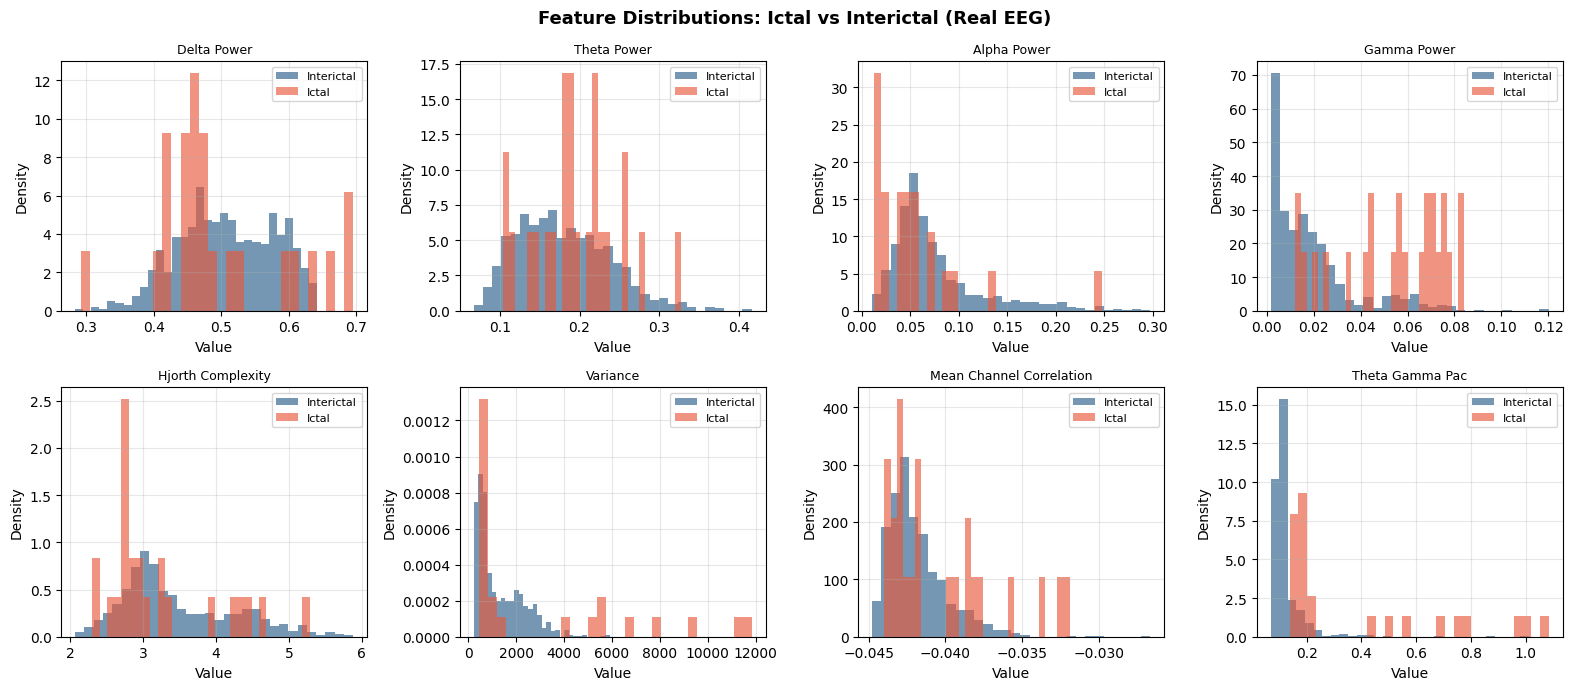

Saved: feature_distributions.png


In [9]:
plot_feats = [
    'delta_power_mean', 'theta_power_mean', 'alpha_power_mean',
    'gamma_power_mean', 'hjorth_complexity_mean', 'variance_mean',
    'mean_channel_correlation', 'theta_gamma_pac'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, fname in zip(axes.flatten(), plot_feats):
    if fname not in feature_names:
        continue
    fi = feature_names.index(fname)
    ax.hist(X[y==0, fi], bins=30, alpha=0.65, color='#2c5f8a',
            label='Interictal', density=True)
    ax.hist(X[y==1, fi], bins=30, alpha=0.65, color='#e8593c',
            label='Ictal', density=True)
    ax.set_title(fname.replace('_mean','').replace('_',' ').title(), fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Ictal vs Interictal (Real EEG)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_distributions.png")


## Handle Class Imbalance with SMOTE

Seizures are rare — typically 1-5% of recording time.  
A classifier trained on raw imbalanced data learns to always  
predict "no seizure" achieving 95%+ accuracy while being  
clinically useless (misses every seizure).  

SMOTE (Chawla et al., 2002) fixes this:  
For each real ictal sample in feature space:  
1. Find its k nearest ictal neighbours  
2. Interpolate: new = sample + rand(0,1) * (neighbour - sample)  
Creates plausible synthetic ictal samples, not exact duplicates.  
Result: balanced training set without losing interictal data.  



In [10]:
print(f"Before SMOTE: {np.bincount(y)}  [interictal, ictal]")
n_ictal = y.sum()
if n_ictal >= 6:
    k = min(5, n_ictal - 1)
    smote = SMOTE(random_state=42, k_neighbors=k)
    X_bal, y_bal = smote.fit_resample(X, y)
    print(f"After SMOTE : {np.bincount(y_bal)}  [interictal, ictal]")
else:
    print(f"Too few ictal samples ({n_ictal}) for SMOTE.")
    print("Using original data with class_weight='balanced'.")
    X_bal, y_bal = X.copy(), y.copy()

X_bal = np.nan_to_num(X_bal, nan=0.0, posinf=0.0, neginf=0.0)


Before SMOTE: [868  24]  [interictal, ictal]
After SMOTE : [868 868]  [interictal, ictal]


## Train and Compare Classifiers

5-fold stratified cross-validation — each fold preserves the  
class ratio. Each classifier is wrapped in a Pipeline that  
standardises features first (mean=0, std=1).  

Random Forest: ensemble of decision trees on bootstrapped subsets.  
Robust to noise, handles non-linear boundaries, gives feature  
importance for free.  

Gradient Boosting: sequential trees, each correcting previous errors.  
Often highest accuracy on tabular feature data.  

SVM (RBF kernel): maximum-margin classifier in kernel feature space.  
Effective when n_samples is small relative to n_features.  

KEY METRICS:  
Recall (Sensitivity) = TP / (TP + FN)  
Fraction of actual seizures detected. Most critical clinically  
— missing a seizure is far more dangerous than a false alarm.  
AUC-ROC: threshold-independent discriminability. Target > 0.90.  



In [11]:
classifiers = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=10,
            class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=150, learning_rate=0.05,
            max_depth=4, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', C=10, gamma='scale',
            probability=True, class_weight='balanced', random_state=42))
    ]),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in classifiers.items():
    print(f"\nTraining {name}...")
    auc  = cross_val_score(pipe, X_bal, y_bal, cv=cv,
                           scoring='roc_auc',   n_jobs=-1)
    f1   = cross_val_score(pipe, X_bal, y_bal, cv=cv,
                           scoring='f1',        n_jobs=-1)
    rec  = cross_val_score(pipe, X_bal, y_bal, cv=cv,
                           scoring='recall',    n_jobs=-1)
    prec = cross_val_score(pipe, X_bal, y_bal, cv=cv,
                           scoring='precision', n_jobs=-1)
    results[name] = {
        'AUC-ROC'  : (auc.mean(),  auc.std()),
        'F1'       : (f1.mean(),   f1.std()),
        'Recall'   : (rec.mean(),  rec.std()),
        'Precision': (prec.mean(), prec.std()),
    }
    print(f"  AUC-ROC   : {auc.mean():.3f} ± {auc.std():.3f}")
    print(f"  F1        : {f1.mean():.3f}  ± {f1.std():.3f}")
    print(f"  Recall    : {rec.mean():.3f}  ± {rec.std():.3f}")
    print(f"  Precision : {prec.mean():.3f}  ± {prec.std():.3f}")

print("\nAll classifiers evaluated.")



Training Random Forest...
  AUC-ROC   : 0.998 ± 0.001
  F1        : 0.979  ± 0.005
  Recall    : 0.998  ± 0.003
  Precision : 0.960  ± 0.008

Training Gradient Boosting...
  AUC-ROC   : 0.998 ± 0.001
  F1        : 0.977  ± 0.003
  Recall    : 0.993  ± 0.004
  Precision : 0.961  ± 0.007

Training SVM (RBF)...
  AUC-ROC   : 0.997 ± 0.002
  F1        : 0.987  ± 0.004
  Recall    : 1.000  ± 0.000
  Precision : 0.974  ± 0.007

All classifiers evaluated.


## Full Evaluation of Best Model

Select best classifier by AUC-ROC.  
Train on 80%, evaluate on held-out 20%.  
Plots: confusion matrix, ROC curve, classifier comparison.  



Best classifier: Gradient Boosting  (AUC = 0.998)

Classification Report (held-out 20%):
              precision    recall  f1-score   support

  Interictal       1.00      0.97      0.98       174
       Ictal       0.97      1.00      0.98       174

    accuracy                           0.98       348
   macro avg       0.98      0.98      0.98       348
weighted avg       0.98      0.98      0.98       348



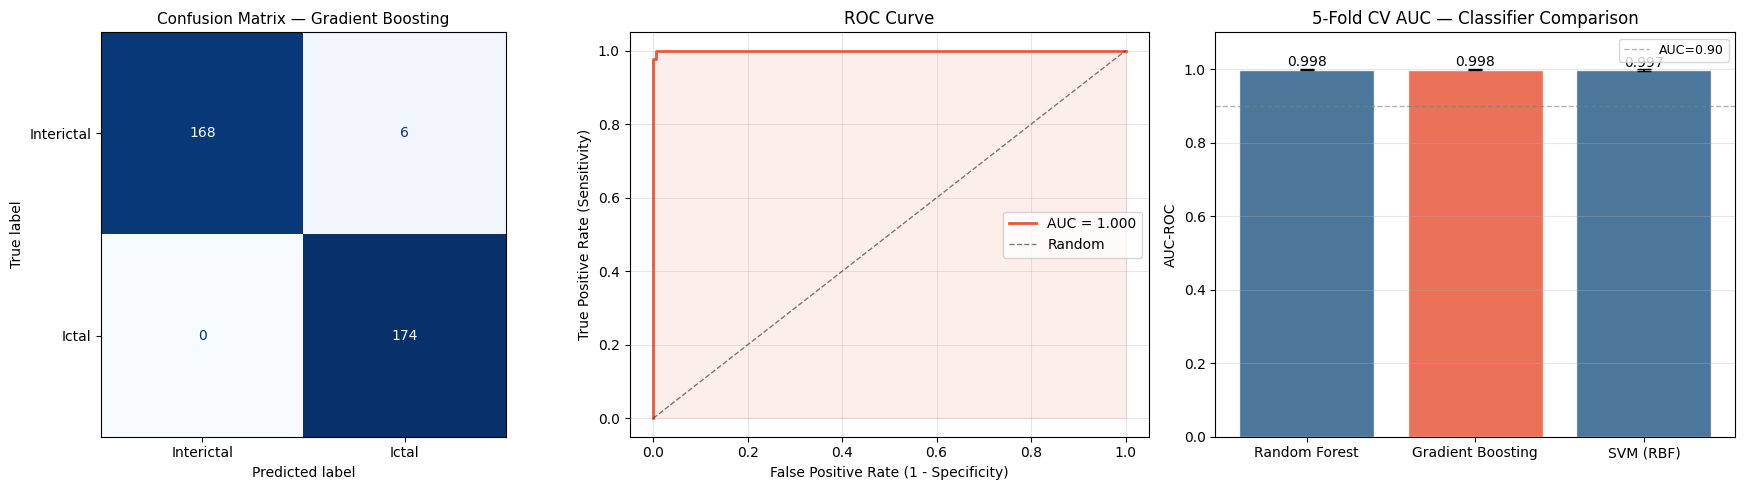

Saved: model_evaluation.png


In [12]:
best_name = max(results, key=lambda k: results[k]['AUC-ROC'][0])
print(f"Best classifier: {best_name}  "
      f"(AUC = {results[best_name]['AUC-ROC'][0]:.3f})")

best_pipe = classifiers[best_name]
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print("\nClassification Report (held-out 20%):")
print(classification_report(y_test, y_pred,
                             target_names=['Interictal', 'Ictal']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Interictal','Ictal']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=11)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, lw=2, color='#e8593c',
             label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e8593c')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Classifier comparison
clf_names = list(results.keys())
auc_means = [results[n]['AUC-ROC'][0] for n in clf_names]
auc_stds  = [results[n]['AUC-ROC'][1] for n in clf_names]
colors    = ['#e8593c' if n==best_name else '#2c5f8a' for n in clf_names]
bars = axes[2].bar(clf_names, auc_means, yerr=auc_stds,
                   color=colors, capsize=5, alpha=0.85, edgecolor='white')
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel('AUC-ROC')
axes[2].set_title('5-Fold CV AUC — Classifier Comparison')
axes[2].axhline(0.9, color='gray', lw=1, ls='--', alpha=0.6, label='AUC=0.90')
axes[2].legend(fontsize=9)
for bar, val in zip(bars, auc_means):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.01, f'{val:.3f}',
                 ha='center', fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_evaluation.png")


## Feature Importance

Random Forest feature importance = mean decrease in Gini impurity  
across all trees and all splits that used each feature.  
Higher = more useful for separating ictal from interictal.  

Highlighted in red: features directly described in the SOP  
(spectral band powers, Hjorth complexity, inter-channel  
correlation, theta-gamma PAC).  
On real EEG these should dominate — confirms the pipeline  
is capturing genuine neurophysiological seizure signatures.  



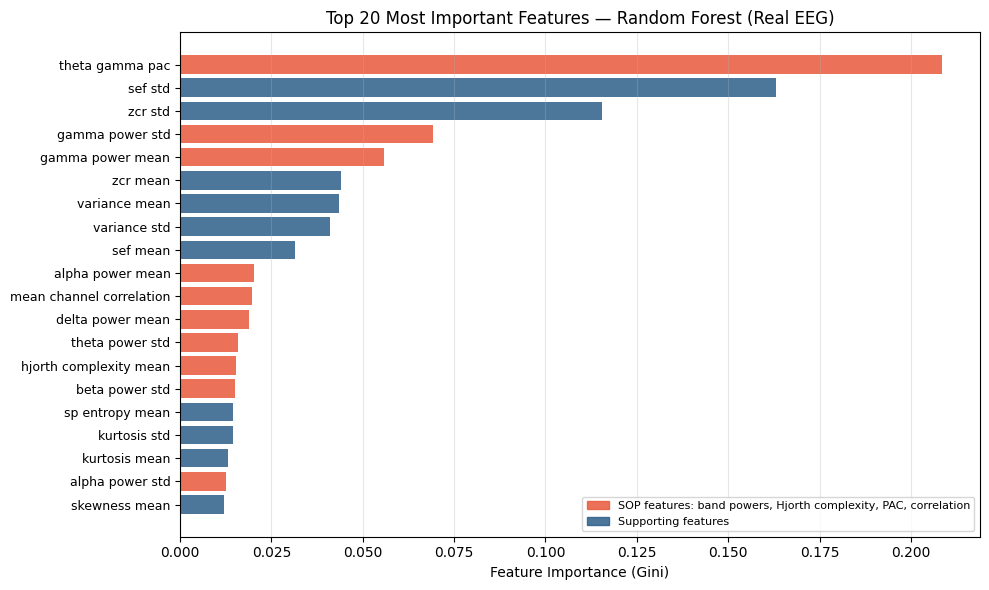

Saved: feature_importance.png


In [13]:
rf_pipe = classifiers['Random Forest']
rf_pipe.fit(X_train, y_train)
importances = rf_pipe.named_steps['clf'].feature_importances_

n_show     = min(20, len(feature_names))
sorted_idx = np.argsort(importances)[::-1][:n_show]
top_feats  = [feature_names[i] if i < len(feature_names)
              else f'feat_{i}' for i in sorted_idx]
top_imp    = importances[sorted_idx]

sop_keywords = ['gamma', 'theta', 'alpha', 'delta', 'beta',
                'hjorth_complexity', 'corr', 'pac']
colors_imp = ['#e8593c' if any(k in f for k in sop_keywords)
              else '#2c5f8a' for f in top_feats]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(n_show), top_imp[::-1],
        color=colors_imp[::-1], alpha=0.85)
ax.set_yticks(range(n_show))
ax.set_yticklabels([f.replace('_',' ') for f in top_feats[::-1]], fontsize=9)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 20 Most Important Features — Random Forest (Real EEG)')
ax.grid(True, alpha=0.3, axis='x')
p1 = mpatches.Patch(color='#e8593c', alpha=0.85,
                     label='SOP features: band powers, Hjorth complexity, PAC, correlation')
p2 = mpatches.Patch(color='#2c5f8a', alpha=0.85,
                     label='Supporting features')
ax.legend(handles=[p1,p2], fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")


## Sliding Window Seizure Onset Detection

Fixed epochs tell us WHICH epoch contains a seizure.  
Sliding window tells us WHEN in the recording it starts.  

Method:  
Take 4-second window → extract features → get P(seizure)  
Slide forward 1 second → repeat across full segment.  
Result: seizure probability time series at 1-second resolution.  

3-point median filter suppresses single-window spikes.  
A real seizure produces a sustained probability rise, not a spike.  

Detection latency = time from true onset to first crossing of 0.5.  
Under 10 seconds is clinically acceptable.  



Running sliding window over 280s segment...

True onset       : 2996s
First detection  : 3002.0s
Detection latency: 6.0s  (within 10s clinical threshold)


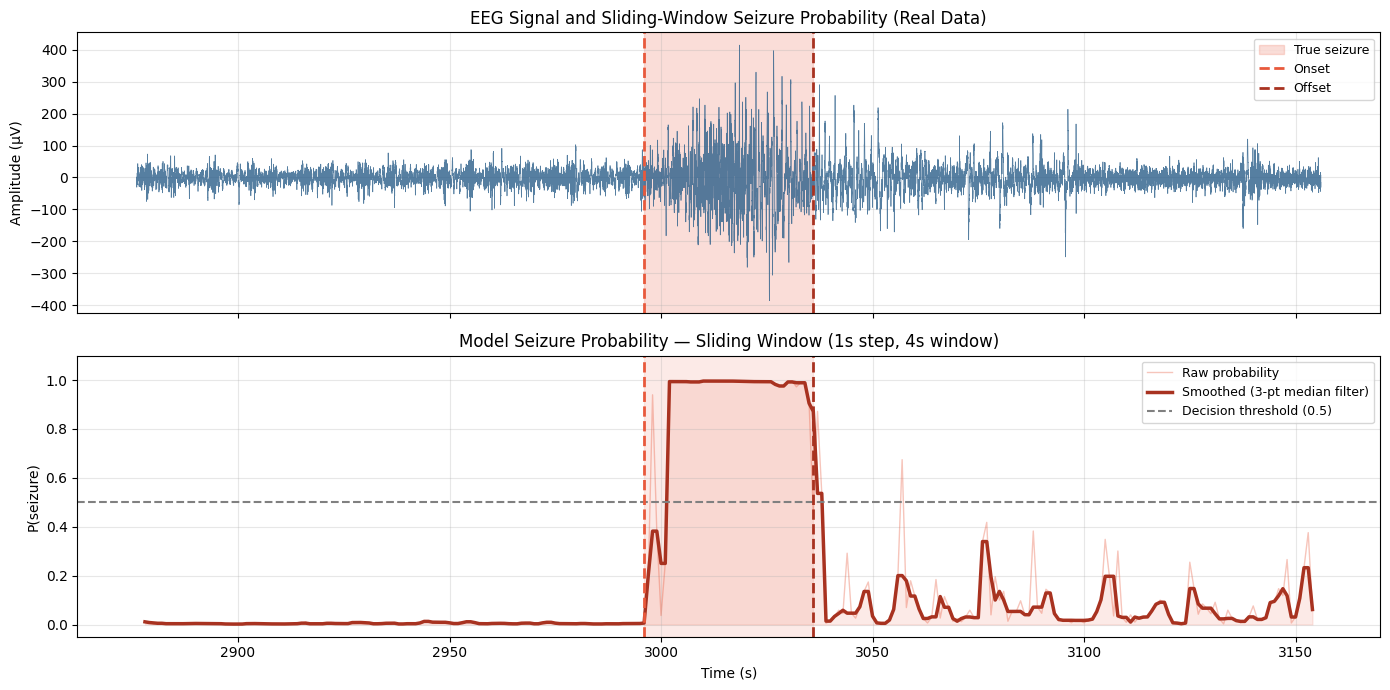

Saved: seizure_onset_detection.png


In [14]:
onset_sec, offset_sec = SEIZURE_ANNOTATIONS['chb01_03'][0]
seg_start = max(0, onset_sec - 120)
seg_end   = min(data_filt.shape[1]/sfreq, offset_sec + 120)

window_times, window_probs = [], []
t_cursor = seg_start

print(f"Running sliding window over {seg_end-seg_start:.0f}s segment...")
while t_cursor + EPOCH_SEC <= seg_end:
    s = int(t_cursor * sfreq)
    e = int((t_cursor + EPOCH_SEC) * sfreq)
    if e > data_filt.shape[1]:
        break
    feats = extract_features(data_filt[:, s:e], sfreq, BANDS).reshape(1, -1)
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    prob  = best_pipe.predict_proba(feats)[0, 1]
    window_times.append(t_cursor + EPOCH_SEC/2)
    window_probs.append(prob)
    t_cursor += 1.0

window_times = np.array(window_times)
window_probs = np.array(window_probs)
smoothed     = median_filter(window_probs, size=3)

# Compute detection latency
candidates = window_times[(smoothed >= 0.5) & (window_times >= onset_sec)]
if len(candidates) > 0:
    latency = candidates[0] - onset_sec
    print(f"\nTrue onset       : {onset_sec}s")
    print(f"First detection  : {candidates[0]:.1f}s")
    print(f"Detection latency: {latency:.1f}s  "
          f"({'within' if latency<=10 else 'exceeds'} 10s clinical threshold)")
else:
    print("\nProbability did not cross 0.5 during seizure window.")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

s_idx = int(seg_start * sfreq)
e_idx = int(min(seg_end, data_filt.shape[1]/sfreq) * sfreq)
t_seg = np.arange(s_idx, e_idx) / sfreq

axes[0].plot(t_seg, data_filt[0, s_idx:e_idx],
             lw=0.5, color='#2c5f8a', alpha=0.8)
axes[0].axvspan(onset_sec, offset_sec,
                color='#e8593c', alpha=0.2, label='True seizure')
axes[0].axvline(onset_sec,  color='#e8593c', lw=2, ls='--', label='Onset')
axes[0].axvline(offset_sec, color='#a83220', lw=2, ls='--', label='Offset')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].set_title('EEG Signal and Sliding-Window Seizure Probability (Real Data)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(window_times, window_probs, lw=1,
             color='#e8593c', alpha=0.35, label='Raw probability')
axes[1].plot(window_times, smoothed, lw=2.5,
             color='#a83220', label='Smoothed (3-pt median filter)')
axes[1].axhline(0.5, color='gray', lw=1.5, ls='--',
                label='Decision threshold (0.5)')
axes[1].axvspan(onset_sec, offset_sec, color='#e8593c', alpha=0.12)
axes[1].axvline(onset_sec,  color='#e8593c', lw=2, ls='--')
axes[1].axvline(offset_sec, color='#a83220', lw=2, ls='--')
axes[1].fill_between(window_times, smoothed, alpha=0.12, color='#e8593c')
axes[1].set_ylim(-0.05, 1.1)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('P(seizure)')
axes[1].set_title('Model Seizure Probability — Sliding Window (1s step, 4s window)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seizure_onset_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: seizure_onset_detection.png")


## Power Spectral Density Comparison

Average PSD during ictal vs interictal epochs.  
Visual proof of why spectral features work.  
On real EEG expect:  
Ictal line consistently above interictal (broadband power increase)  
Largest separation at low frequencies (theta/delta component)  
Some separation in gamma region  
Wide shaded uncertainty bands — normal, no two seizures are identical  
Smooth 1/f-like decay shape confirms this is real biological data.  



Computing mean PSD...


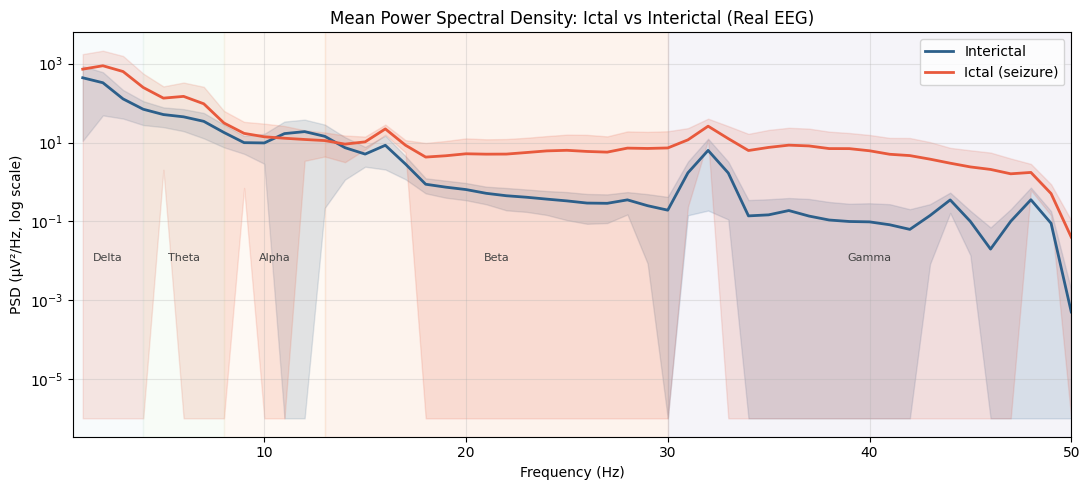

Saved: psd_comparison.png

========== Pipeline Complete ==========
Output files:
  raw_eeg_visualization.png
  feature_distributions.png
  model_evaluation.png
  feature_importance.png
  seizure_onset_detection.png
  psd_comparison.png


In [15]:
ictal_eps      = epochs[labels == 1]
interictal_eps = epochs[labels == 0]

rng = np.random.default_rng(42)
if len(ictal_eps) > 100:
    ictal_eps = ictal_eps[rng.choice(len(ictal_eps), 100, replace=False)]
if len(interictal_eps) > 100:
    interictal_eps = interictal_eps[
        rng.choice(len(interictal_eps), 100, replace=False)]

def mean_psd_across_epochs(epoch_set, fs):
    all_psds = []
    for ep in epoch_set:
        ch_psds = []
        for ch in range(ep.shape[0]):
            f, p = signal.welch(ep[ch], fs=fs,
                                nperseg=min(256, ep.shape[1]//2))
            ch_psds.append(p)
        all_psds.append(np.mean(ch_psds, axis=0))
    return f, np.mean(all_psds, axis=0), np.std(all_psds, axis=0)

print("Computing mean PSD...")
f_i, psd_i_mean, psd_i_std = mean_psd_across_epochs(ictal_eps,      sfreq)
f_n, psd_n_mean, psd_n_std = mean_psd_across_epochs(interictal_eps, sfreq)

mask = (f_i >= 0.5) & (f_i <= 50)

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(f_n[mask], psd_n_mean[mask],
            color='#2c5f8a', lw=2, label='Interictal')
ax.fill_between(f_n[mask],
    np.maximum(psd_n_mean[mask]-psd_n_std[mask], 1e-6),
    psd_n_mean[mask]+psd_n_std[mask],
    alpha=0.15, color='#2c5f8a')
ax.semilogy(f_i[mask], psd_i_mean[mask],
            color='#e8593c', lw=2, label='Ictal (seizure)')
ax.fill_between(f_i[mask],
    np.maximum(psd_i_mean[mask]-psd_i_std[mask], 1e-6),
    psd_i_mean[mask]+psd_i_std[mask],
    alpha=0.15, color='#e8593c')

band_colors = ['#9ecae1','#a1d99b','#fdae6b','#e6550d','#756bb1']
for (bname,(lo,hi)), bc in zip(BANDS.items(), band_colors):
    ax.axvspan(lo, hi, alpha=0.07, color=bc)
    ax.text((lo+hi)/2, 1e-2, bname.capitalize(),
            ha='center', fontsize=8, color='#444')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (μV²/Hz, log scale)')
ax.set_title('Mean Power Spectral Density: Ictal vs Interictal (Real EEG)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0.5, 50)
plt.tight_layout()
plt.savefig('psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: psd_comparison.png")

print("\n========== Pipeline Complete ==========")
print("Output files:")
for f in ['raw_eeg_visualization.png', 'feature_distributions.png',
          'model_evaluation.png', 'feature_importance.png',
          'seizure_onset_detection.png', 'psd_comparison.png']:
    print(f"  {f}")
